### 42028 : Deep Learning and CNN
### Assignment 2

| Name | Swapnil Ajit Chhatre |
| :--- | :--- |
| Student ID | 25675238 |
| Tutorial | 04 (Wednesday 12.00 - 15.00) |
| Tutor | Mr. Deep Patel |

#### Aim
- To perform Image Classification using baseline CNN and customized CNN architectures

### Contents
1. Section 1 : Loading Dataset
2. Section 2 : Exploratory Data Analysis
3. Section 3 : Data Augmentation
4. Section 4 : Custom VGG16 Modelling
5. Section 5 : Custom ResNet18 Modelling

### Drive Mounting

In [1]:
from google.colab import drive
drive.mount('/content/drive/')

Mounted at /content/drive/


In [2]:
# !unzip ./drive/MyDrive/UTS_Academics/42904_Deep_Learning/Assignment_2/student_25675238.zip -d ./drive/MyDrive/UTS_Academics/42904_Deep_Learning/Assignment_2/

### System GPU Checks

In [ ]:
#Check GPU
!nvidia-smi

In [2]:
!find / -type f -name "libdevice.10.bc" 2>/dev/null

/opt/conda/lib/python3.12/site-packages/triton/backends/nvidia/lib/libdevice.10.bc


/opt/conda/nvvm/libdevice/libdevice.10.bc


### Library Imports

In [3]:
!pip install opencv-python --quiet

In [4]:
!pip install pydot

In [ ]:
!pip install silence-tensorflow

In [5]:
# Importing required libraries and setting global variables
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pydot
import random
import tensorflow as tf
import keras

2026-05-08 08:57:28.431269: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-08 08:57:28.444827: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778230648.462623    2300 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778230648.468146    2300 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-05-08 08:57:28.485961: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [ ]:
dataset_path = './25675238/Image_Classification/dataset'
data_files_path = './data_files/Image_Classification'
results_files_path = './results_and_models'
os.environ['XLA_FLAGS'] = '--xla_gpu_cuda_data_dir=/opt/conda'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from keras import models
from keras import layers
from keras import optimizers
from keras.applications import VGG16, ResNet50
from keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from keras.optimizers import RMSprop, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
tf.get_logger().setLevel('ERROR')
silence_tensorflow()

### Section 1 : Loading Dataset

In [7]:
classes = os.listdir(dataset_path)

In [ ]:
#Renaming folder names to lowercase # This operation is for one-time execution
# for folder in classes:
#     folder_path = os.path.join(dataset_path, folder)
#     new_path = os.path.join(dataset_path, folder.lower())
#     os.rename(folder_path, new_path)

In [6]:
classes = os.listdir(dataset_path)

In [7]:
classes

['borzoi',
 'toy_terrier',
 'wire-haired_fox_terrier',
 'schipperke',
 'chihuahua',
 'sussex_spaniel',
 'bernese_mountain_dog',
 'norwegian_elkhound',
 'german_short-haired_pointer',
 'brittany_spaniel']

In [8]:
!find ./25675238/Image_Classification/dataset -maxdepth 2 -type f -iname "*.jpg" -printf '%h\n' | sort | uniq -c | awk -F'/' '{printf "%-30s : %s images\n", $NF, $1}'

bernese_mountain_dog           :     218 . images
borzoi                         :     151 . images
brittany_spaniel               :     152 . images
chihuahua                      :     152 . images
german_short-haired_pointer    :     152 . images
norwegian_elkhound             :     196 . images
schipperke                     :     154 . images
sussex_spaniel                 :     151 . images
toy_terrier                    :     172 . images
wire-haired_fox_terrier        :     157 . images


In [9]:
!find ./25675238/Image_Classification/dataset -maxdepth 2 -type f -iname "*.jpg" | wc -l | awk '{printf "Total number of images : %s", $1}'

Total number of images : 1655

### Section 2 : Exploratory Data Analysis

*In this section, we explore the characteristics of this dataset. We will use OpenCV library to access and examine the images*

*As shown in the previous sections, the dataset contains of 10 classes of dog images.*

*Each class consists of different number of images, bringing the total number of images to 1655.*

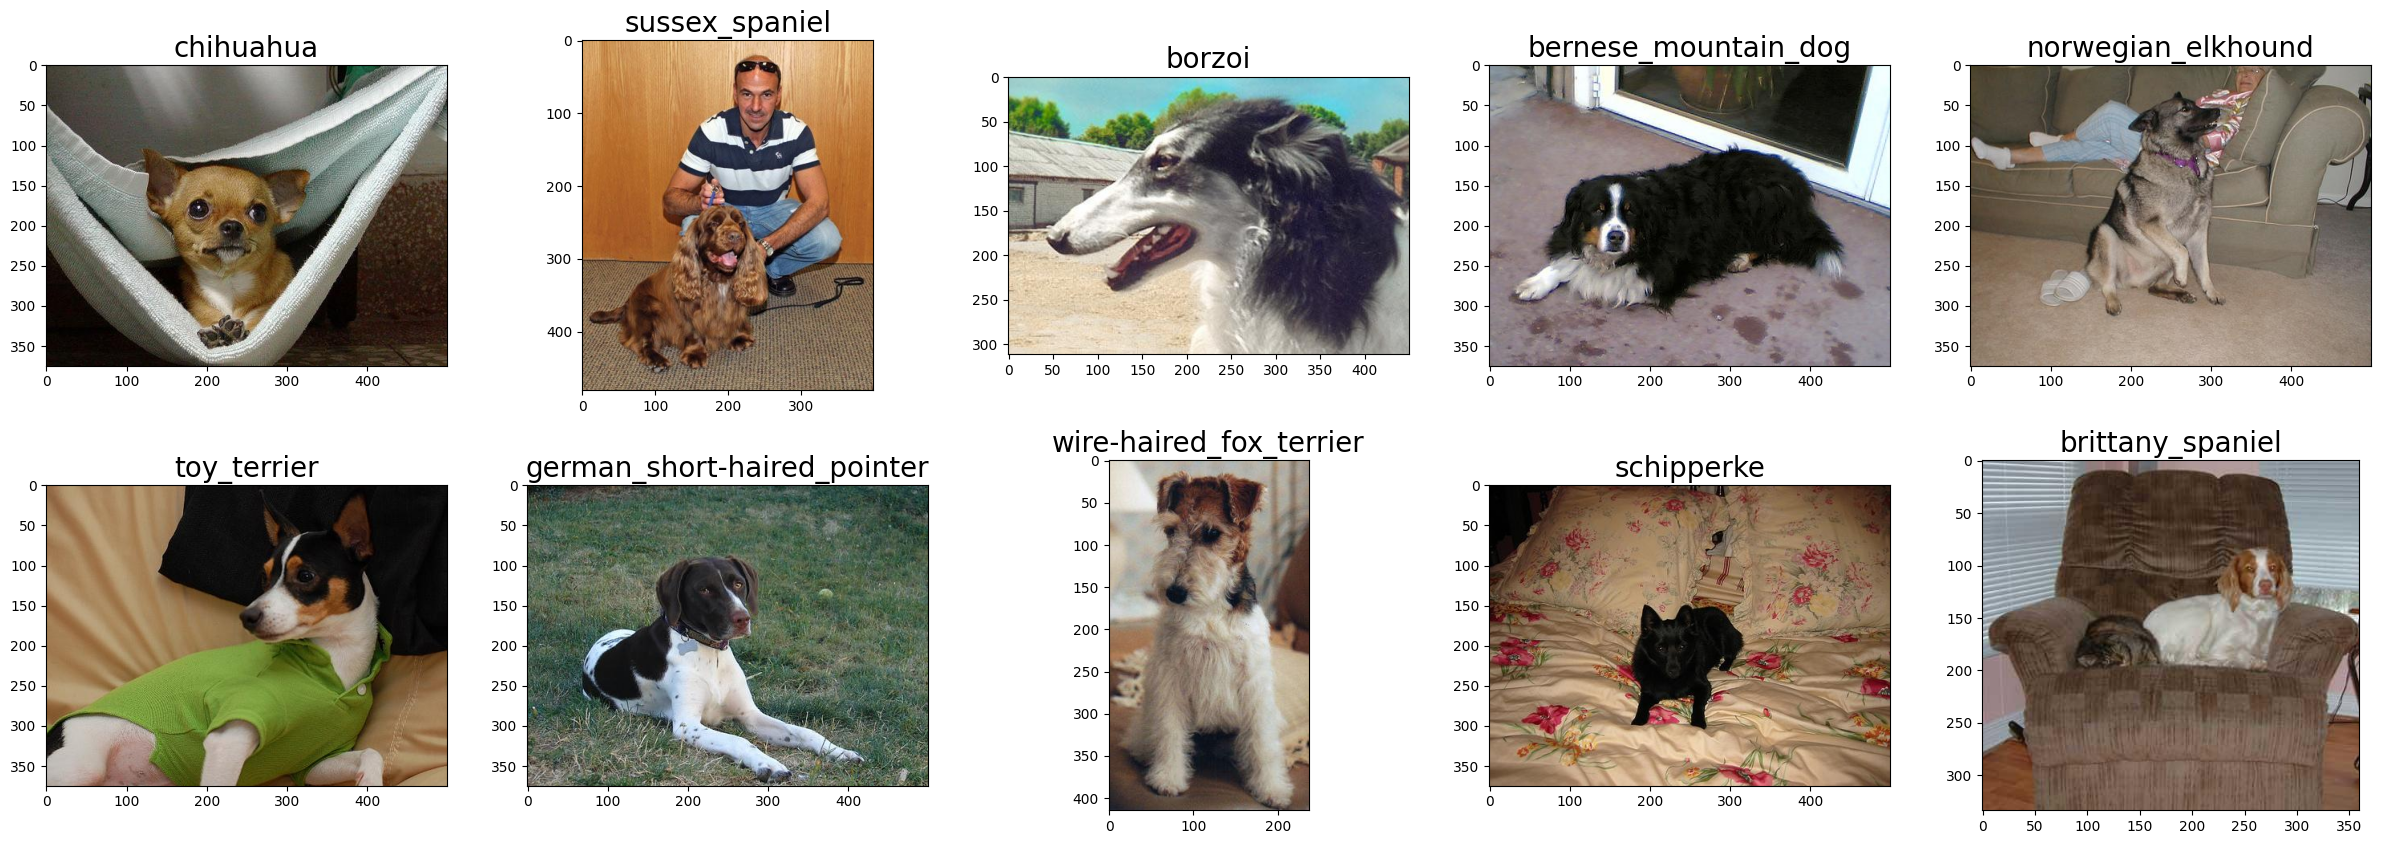

In [ ]:
#Analysing images from every class

fig, axes = plt.subplots(nrows=2, ncols=5, figsize=(30,10))
class_idx = 0
for i in range(2):
    for j in range(5):
        folder_path = dataset_path + "/" + classes[class_idx]
        images_path = os.listdir(folder_path)
        img_idx = random.randint(0, len(images_path) - 1) # Showing a random image for the same class on every run
        img = cv2.imread(folder_path + "/" + images_path[img_idx])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes[i,j].imshow(img)
        axes[i,j].set_title(classes[class_idx], fontsize=20)
        class_idx += 1
plt.show()

In [ ]:
#Printing image shape
image = cv2.imread(dataset_path + '/bernese_mountain_dog/01.jpg')
print("Image dimensions :", image.shape)
print("Image data type :", image.dtype)
print("Image width :", image.shape[0])
print("Image length :", image.shape[1])

Image dimensions : (333, 500, 3)
Image data type : uint8
Image width : 333
Image length : 500


*It can be observed that the images have 3 (RGB) channels.*

All images analysed for class :  chihuahua
All images analysed for class :  sussex_spaniel
All images analysed for class :  borzoi
All images analysed for class :  bernese_mountain_dog
All images analysed for class :  norwegian_elkhound
All images analysed for class :  toy_terrier
All images analysed for class :  german_short-haired_pointer
All images analysed for class :  wire-haired_fox_terrier
All images analysed for class :  schipperke
All images analysed for class :  brittany_spaniel


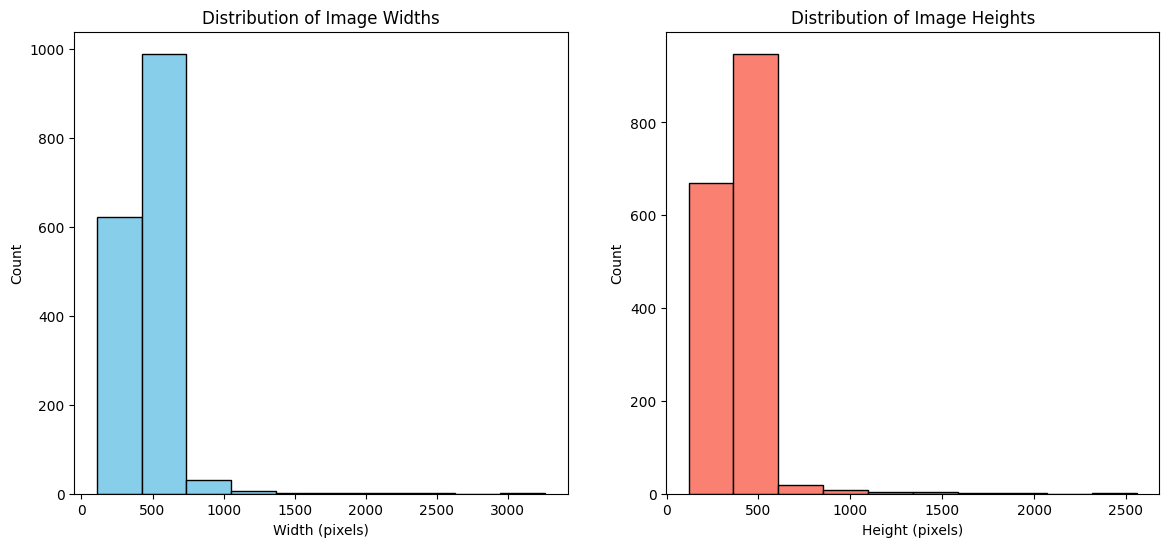

In [ ]:
#Gathering image widths and heights and observing their distribution
widths = []
heights = []

#While traversing all images and labels, store them into separate arrays
#The images array will contain the image while the labels array will contain the class name as the label for that image
images = []
labels = []

for class_name in classes:
    folder_path = dataset_path + "/" + class_name
    images_path = os.listdir(folder_path)
    for i in images_path:
        img_path = folder_path + "/" + i
        img = cv2.imread(img_path)
        h, w = img.shape[:2]
        widths.append(w)
        heights.append(h)

        images.append(img)
        labels.append(class_name)
    print("All images analysed for class : ", class_name)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Width Histogram
ax1.hist(widths, bins=10, color='skyblue', edgecolor='black')
ax1.set_title('Distribution of Image Widths')
ax1.set_xlabel('Width (pixels)')
ax1.set_ylabel('Count')

# Height Histogram
ax2.hist(heights, bins=10, color='salmon', edgecolor='black')
ax2.set_title('Distribution of Image Heights')
ax2.set_xlabel('Height (pixels)')
ax2.set_ylabel('Count')

plt.show()

*It can be observed that all images belonging to the 10 classes have varied heights and widths which requires further processing before ingesting them into the CNN model.*

*From the obove mentioned distribtion it can be seen that maximum images have heights and widths around 500px, which is a significantly larger image for CNN training*

In [ ]:
#Writing the raw images and labels to .npy files for reuse
images_np_array = np.array(images, dtype=object)
labels_np_array = np.array(labels, dtype=object)

np.savez(data_files_path + '/original_images.npz', images_np_array)
np.savez(data_files_path + '/original_labels.npz', labels_np_array)

### Section 3 : Original data loading and Augmentation

In [41]:
# Loading the preprocessed images from npz files
with np.load(data_files_path + '/original_images.npz', allow_pickle=True) as data:
    images = list(data['arr_0'])

In [42]:
# Loading the original labels from the npz files
with np.load(data_files_path + '/original_labels.npz', allow_pickle=True) as data:
    labels = list(data['arr_0'])

In [43]:
# Encoding labels
encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)

In [44]:
# Creating training and testing sets
images_train, images_test, labels_train, labels_test = train_test_split(
    images, encoded_labels,
    test_size=0.15,
    train_size=0.85,
    random_state=25675238 #Using student ID as random seed
)

In [45]:
# Creating validation set
images_valid = images_train[:250]
labels_valid = labels_train[:250]

images_train = images_train[250:]
labels_train = labels_train[250:]

*The dataset is initially split into 85% training set and 15% testing set.*

*The training set is split into another 70% and 15% validation set*

In [48]:
# Image resizing
# The images of variable length are resized to 224x224 to standardize the input to the baseline models
resize_train_image = []
resize_valid_image = []
resize_test_image = []

for img in images_train:
    rsz_img = cv2.resize(img, (224, 224))
    resize_train_image.append(rsz_img)
for img in images_valid:
    rsz_img = cv2.resize(img, (224, 224))
    resize_valid_image.append(rsz_img)
for img in images_test:
    rsz_img = cv2.resize(img, (224, 224))
    resize_test_image.append(rsz_img)

In [49]:
images_train = np.asarray(resize_train_image).astype('float32')
images_valid = np.asarray(resize_valid_image).astype('float32')
images_test = np.asarray(resize_test_image).astype('float32')

In [50]:
labels_train = np.asarray(labels_train)
labels_valid = np.asarray(labels_valid)
labels_test = np.asarray(labels_test)

In [51]:
classes = os.listdir(dataset_path)
classes

['borzoi',
 'toy_terrier',
 'wire-haired_fox_terrier',
 'schipperke',
 'chihuahua',
 'sussex_spaniel',
 'bernese_mountain_dog',
 'norwegian_elkhound',
 'german_short-haired_pointer',
 'brittany_spaniel']

In [66]:
# Creating augmentation samples for visualization
augmented_samples_path = './augmented_samples'

datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

for name in classes:
    i = 0
    for batch in datagen.flow(
        images_train,
        labels_train,
        batch_size=1,
        save_to_dir=augmented_samples_path, 
        save_prefix=f'aug_{name}', 
        save_format='jpeg'
    ):
        i += 1
        if i >= 2:
            break 
    print(f"Created 2 samples for {name}")

# Cleanup augmented samples
!rm -r ./augmented_samples/.ipynb_checkpoints

Created 2 samples for borzoi
Created 2 samples for toy_terrier
Created 2 samples for wire-haired_fox_terrier
Created 2 samples for schipperke
Created 2 samples for chihuahua
Created 2 samples for sussex_spaniel
Created 2 samples for bernese_mountain_dog
Created 2 samples for norwegian_elkhound
Created 2 samples for german_short-haired_pointer
Created 2 samples for brittany_spaniel
rm: cannot remove './augmented_samples/.ipynb_checkpoints': No such file or directory


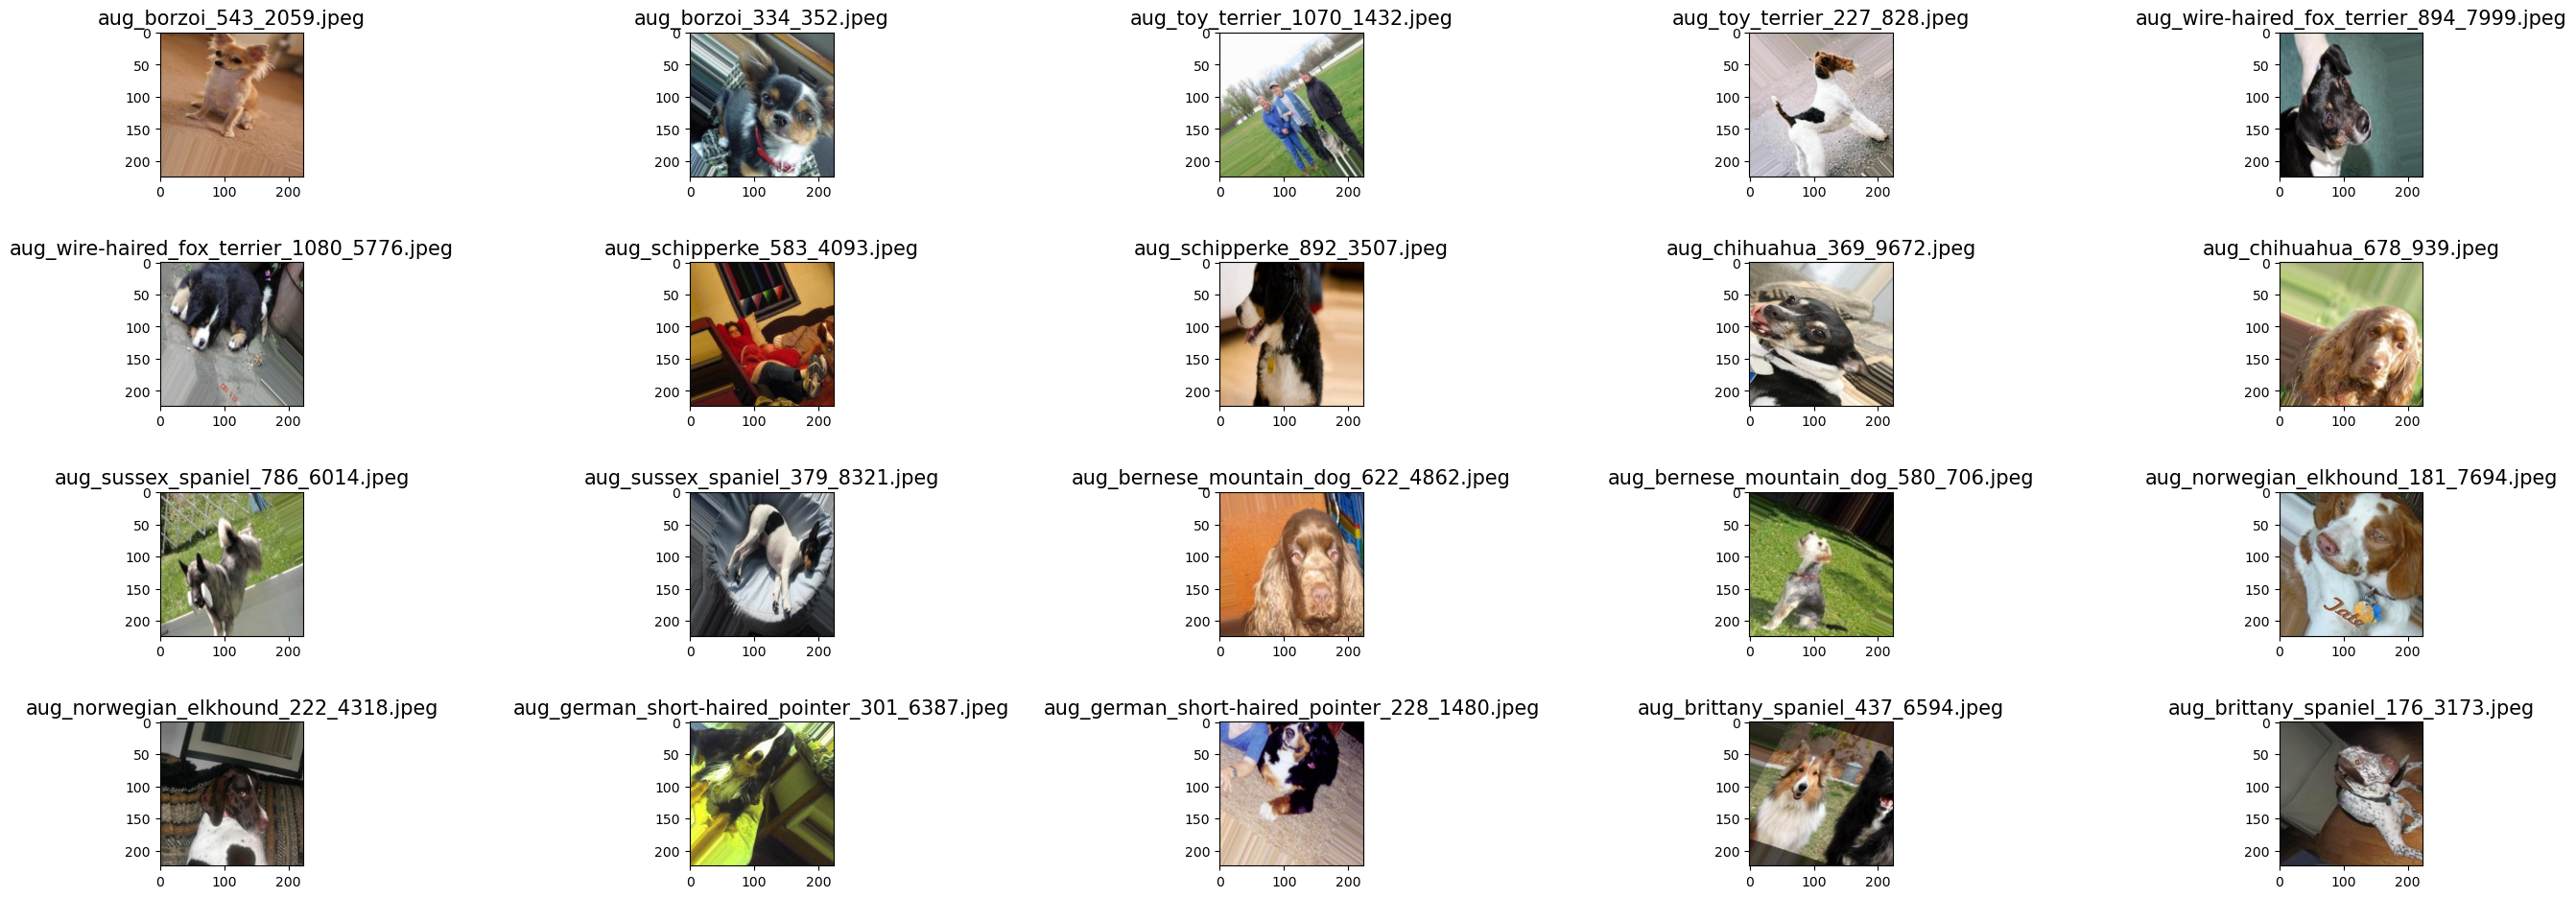

In [67]:
# Analysing augmented images from every class

fig, axes = plt.subplots(nrows=4, ncols=5, figsize=(30,10))
augmented_images = os.listdir(augmented_samples_path)
aug_img_idx = 0
for i in range(4):
    for j in range(5):
        img = cv2.imread(augmented_samples_path + "/" + augmented_images[aug_img_idx])
        axes[i,j].imshow(img)
        axes[i,j].set_title(augmented_images[aug_img_idx], fontsize=15)
        aug_img_idx += 1
plt.tight_layout(pad=3.0)
plt.show()

In [65]:
# Cleanup augmented samples
!rm -rf ./augmented_samples/*

In [68]:
train_datagen = ImageDataGenerator(
      rescale=1./255,
      rotation_range=40,
      width_shift_range=0.2,
      height_shift_range=0.2,
      shear_range=0.2,
      zoom_range=0.2,
      horizontal_flip=True,
      fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale=1./255)

# Flow training images in batches of 20 using train_datagen generator
train_generator = train_datagen.flow(
        images_train,
        labels_train,
        batch_size=36,
        seed=25675238
        )

# Flow validation images in batches of 20 using test_datagen generator
validation_generator = test_datagen.flow(
        images_valid,
        labels_valid,
        batch_size=36,
        )

### Section 3 : Baseline CNN Modelling (VGG16) on Original Data

In [50]:
# Using VGG16 model with pretrained weights
conv_base = VGG16(weights='imagenet',include_top=False, input_shape=(224, 224, 3))
model = models.Sequential()
model.add(conv_base)
model.add(layers.Flatten())
model.add(layers.Dense(256, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))

I0000 00:00:1778154587.746790     590 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


In [51]:
for layer in conv_base.layers:
    layer.trainable = False

In [52]:
model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [53]:
filepath = './results_and_models/baseline_weights/weights_modified.{epoch:02d}-{val_loss:.2f}.keras'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    save_freq='epoch'
)

#### VGG16 Model Fit

In [54]:
# Train the model
history = model.fit(
    train_generator,
    epochs=100,
    steps_per_epoch = 32,
    validation_data=validation_generator,
    validation_steps=8,
    callbacks = [checkpoint],
    verbose=2
    )

Epoch 1/100


I0000 00:00:1778154632.425669    2679 service.cc:148] XLA service 0x7f4f880090d0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778154632.425702    2679 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-05-07 11:50:32.544060: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778154632.893370    2679 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-07 11:50:33.645335: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[36,64,224,224]{3,2,1,0}, u8[0]{0}) custom-call(f32[36,3,224,224]{3,2,1,0}, f32[64,3,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activa


Epoch 1: val_accuracy improved from None to 0.47200, saving model to ./results_and_models/baseline_weights/weights_modified.01-1.65.keras


/opt/conda/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


32/32 - 45s - 1s/step - accuracy: 0.2304 - loss: 2.2186 - val_accuracy: 0.4720 - val_loss: 1.6476
Epoch 2/100

Epoch 2: val_accuracy improved from 0.47200 to 0.55600, saving model to ./results_and_models/baseline_weights/weights_modified.02-1.57.keras
32/32 - 2s - 73ms/step - accuracy: 0.4167 - loss: 1.7074 - val_accuracy: 0.5560 - val_loss: 1.5686
Epoch 3/100

Epoch 3: val_accuracy improved from 0.55600 to 0.56000, saving model to ./results_and_models/baseline_weights/weights_modified.03-1.26.keras
32/32 - 14s - 434ms/step - accuracy: 0.4705 - loss: 1.6658 - val_accuracy: 0.5600 - val_loss: 1.2632
Epoch 4/100

Epoch 4: val_accuracy improved from 0.56000 to 0.57200, saving model to ./results_and_models/baseline_weights/weights_modified.04-1.22.keras
32/32 - 2s - 75ms/step - accuracy: 0.4167 - loss: 1.5561 - val_accuracy: 0.5720 - val_loss: 1.2152
Epoch 5/100

Epoch 5: val_accuracy improved from 0.57200 to 0.70800, saving model to ./results_and_models/baseline_weights/weights_modified.0

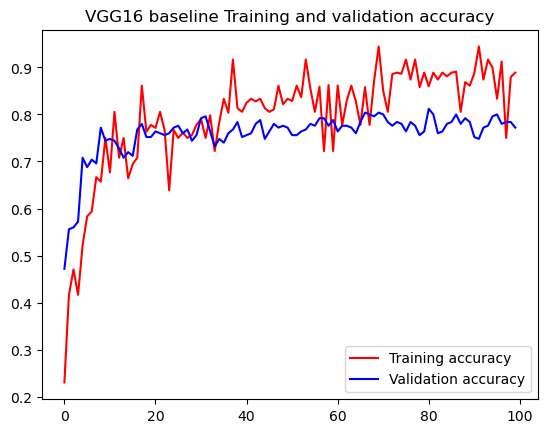

<Figure size 640x480 with 0 Axes>

In [59]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('VGG16 baseline Training and validation accuracy')
plt.legend()
plt.show()
plt.savefig('./results_and_models/VGG16_Baseline_Accuracy.png')

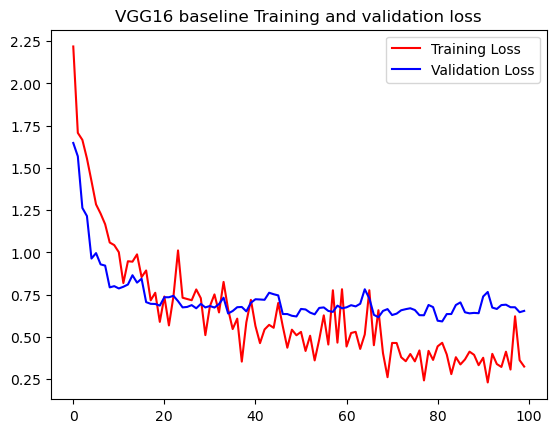

In [60]:
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('VGG16 baseline Training and validation loss')
plt.legend()
plt.savefig('./results_and_models/VGG16_Baseline_Loss.png')

### Section 4 : Baseline CNN Modelling (ResNet50) on Original Data

In [69]:
# Using ResNet50 model with pretrained weights
conv_base_res = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
model_res = models.Sequential()
model_res.add(conv_base_res)
model_res.add(layers.Flatten())
model_res.add(layers.Dense(10, activation='softmax'))

I0000 00:00:1778232857.556734    2300 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:1e.0, compute capability: 7.5


In [70]:
# for layer in conv_base_res.layers:
#     layer.trainable = False

In [71]:
model_res.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [72]:
filepath = './results_and_models/baseline_resnet_weights/weights_modified.{epoch:02d}-{val_loss:.2f}.keras'

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath,
    monitor='val_accuracy',
    verbose=1,
    save_best_only=True,
    save_weights_only=False,
    mode='max',
    save_freq='epoch'
)

#### ResNet50 Model Fit

In [73]:
# Train the model
history = model_res.fit(
    train_generator,
    epochs=100,
    steps_per_epoch = 32,
    validation_data=validation_generator,
    validation_steps=8,
    callbacks = [checkpoint],
    verbose=2
    )

Epoch 1/100


I0000 00:00:1778232905.580191    4657 service.cc:148] XLA service 0x7f87e8002950 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778232905.580230    4657 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-05-08 09:35:06.775132: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1778232910.107977    4657 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-08 09:35:12.411980: I external/local_xla/xla/service/gpu/autotuning/conv_algorithm_picker.cc:557] Omitted potentially buggy algorithm eng14{k25=2} for conv (f32[36,64,56,56]{3,2,1,0}, u8[0]{0}) custom-call(f32[36,64,56,56]{3,2,1,0}, f32[64,64,3,3]{3,2,1,0}, f32[64]{0}), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBiasActivationForward", backend_config={"cudnn_conv_backend_config":{"activati


Epoch 1: val_accuracy improved from None to 0.08400, saving model to ./results_and_models/baseline_resnet_weights/weights_modified.01-4.45.keras


/opt/conda/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


32/32 - 96s - 3s/step - accuracy: 0.5857 - loss: 1.6830 - val_accuracy: 0.0840 - val_loss: 4.4451
Epoch 2/100

Epoch 2: val_accuracy did not improve from 0.08400
32/32 - 1s - 30ms/step - accuracy: 0.7500 - loss: 0.6051 - val_accuracy: 0.0840 - val_loss: 4.5314
Epoch 3/100

Epoch 3: val_accuracy did not improve from 0.08400
32/32 - 13s - 394ms/step - accuracy: 0.8848 - loss: 0.4303 - val_accuracy: 0.0840 - val_loss: 3.2681
Epoch 4/100

Epoch 4: val_accuracy improved from 0.08400 to 0.08800, saving model to ./results_and_models/baseline_resnet_weights/weights_modified.04-3.23.keras
32/32 - 2s - 68ms/step - accuracy: 0.8889 - loss: 0.4723 - val_accuracy: 0.0880 - val_loss: 3.2266
Epoch 5/100

Epoch 5: val_accuracy improved from 0.08800 to 0.09200, saving model to ./results_and_models/baseline_resnet_weights/weights_modified.05-5.72.keras
32/32 - 14s - 431ms/step - accuracy: 0.8955 - loss: 0.4118 - val_accuracy: 0.0920 - val_loss: 5.7239
Epoch 6/100

Epoch 6: val_accuracy did not improve f

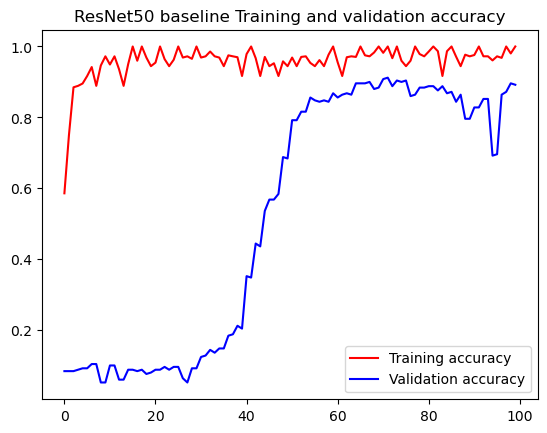

<Figure size 640x480 with 0 Axes>

In [77]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('ResNet50 baseline Training and validation accuracy')
plt.legend()
plt.show()
plt.savefig('./results_and_models/ResNet50_Baseline_Accuracy.png')

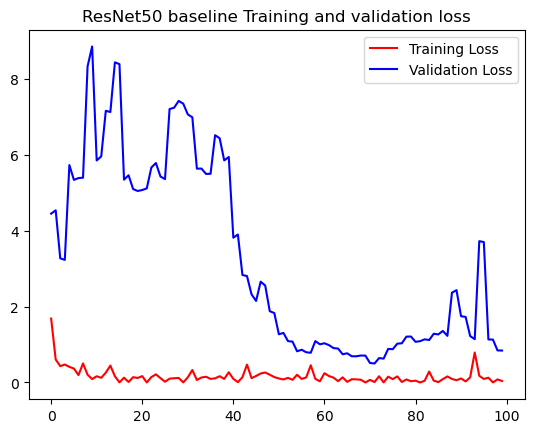

In [78]:
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('ResNet50 baseline Training and validation loss')
plt.legend()
plt.savefig('./results_and_models/ResNet50_Baseline_Loss.png')